**Large-Scale Data Mining: Models and Algorithms**  
*Prof. Vwani Roychowdhury*  

**Winter 2025**  
UCLA, Department of ECE  

---

# **Project 4: Regression Analysis and Define Your Own Task!**

---

**Due on Mar 14, 2025, 11:59 pm**

**Team Members**: Brair Tilboon Elberier, Marc Hernandez, Kunbo Ma

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor

In [ ]:
drive.mount('/content/drive')
file_path_wine_red = "/content/drive/MyDrive/wine_quality/winequality-red.csv"
file_path_wine_white = "/content/drive/MyDrive/wine_quality/winequality-white.csv"

# file_path_wine_red = "./wine_quality/winequality-red.csv"
# file_path_wine_white = "./wine_quality/winequality-white.csv"

Mounted at /content/drive


## 1. Introduction
Regression analysis is a statistical procedure for estimating the relationship between a
target variable and a set of features that jointly inform about the target. In this project,
we explore specific-to-regression feature engineering methods and model selection that
jointly improve the performance of regression. You will conduct different experiments
and identify the relative significance of the different options.

## 2. Datasets
You should take steps in section 3 on either one of the following datasets.

In [ ]:
data_red = pd.read_csv(file_path_wine_red, delimiter=';')
data_white = pd.read_csv(file_path_wine_white, delimiter=';')

data_red['type'] = 1
data_white['type'] = 0
data = pd.concat([data_red, data_white], ignore_index=True)
print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  type  
0      9.4        5     1  
1      9.8        5     1  
2 

## 3. Required Steps
In this section, we describe the setup you need to follow. Follow these steps to process
either of the datasets in Section 2.
### 3.1 Before Training
Before training an algorithm, it’s always essential to inspect the data. This provides
intuition about the quality and quantity of the data and suggests ideas to extract features
for downstream ML applications. In this following section we will address these steps.
### 3.1.1 Handling Categorical Features
A categorical feature is a feature that can take on one of a limited number of possible
values. If one dataset contains categorical features, a preprocessing step needs to be
carried to convert categorical variables into numbers and thus prepared for training.
One method for numerical encoding of categorical features is to assign a scalar. For
instance, if we have a “Quality” feature with values {Poor, Fair, Typical, Good,
Excellent} we might replace them with numbers 1 through 5. If there is no numerical
meaning behind categorical features (e.g. {Cat, Dog}) one has to perform “one-hot
encoding” instead.

### 3.1.2 Data Inspection
The first step for data analysis is to take a close look at the dataset1.

### Question 1.1
Plot a heatmap of the Pearson correlation matrix of the dataset columns. Report
which features have the highest absolute correlation with the target variable. In the context of either dataset, describe what the correlation patterns suggest.

### Answer 1.1



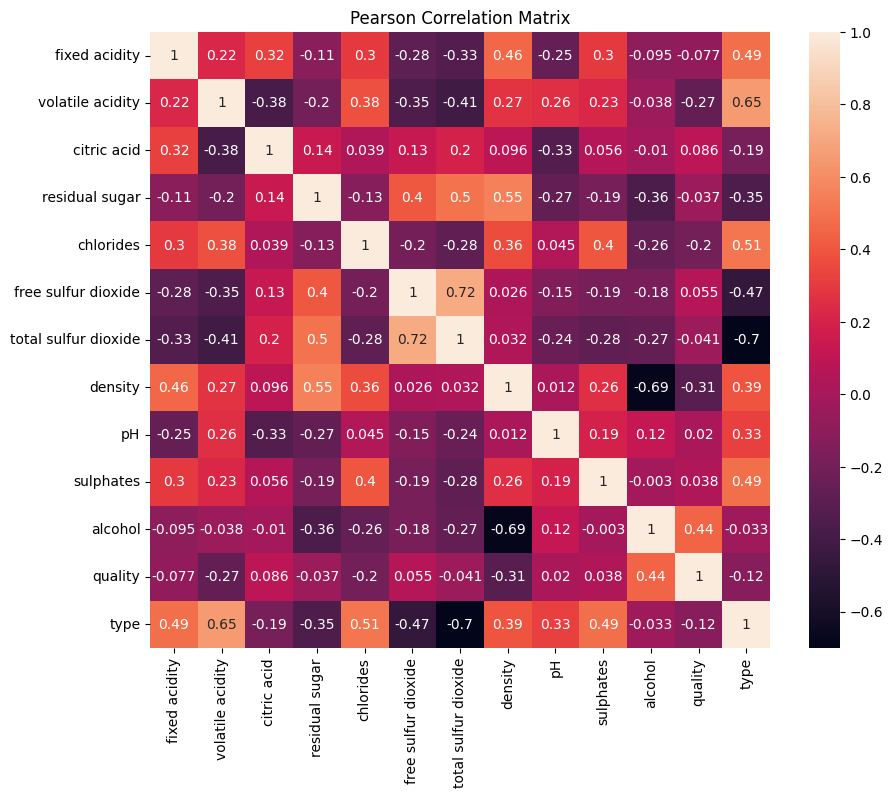

The best Correlating Features to describe quality of wine quality                 1.000000
alcohol                 0.444319
density                 0.305858
volatile acidity        0.265699
chlorides               0.200666
type                    0.119323
citric acid             0.085532
fixed acidity           0.076743
free sulfur dioxide     0.055463
total sulfur dioxide    0.041385
sulphates               0.038485
residual sugar          0.036980
pH                      0.019506
Name: quality, dtype: float64


In [ ]:
# code for 1.1
corr_matrix= data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title("Pearson Correlation Matrix")
plt.show()

best_corr_red = corr_matrix['quality'].abs().sort_values(ascending=False)

print("The best Correlating Features to describe quality of wine", best_corr_red)

Based on these results we'll notice that the features with the strongest correlation to the quality of red wine are Alcohol and Volitial Acidity, while for white wine, the strongest correlating features are Alcohol and Density. This suggests that the alcohol content if a wine is one of the most important features when determining the quality of a wine and the same can be said about density.

### Question 1.2
Plot the histogram of numerical features. What preprocessing can be done if the
distribution of a feature has high skewness?

### Answer 1.2

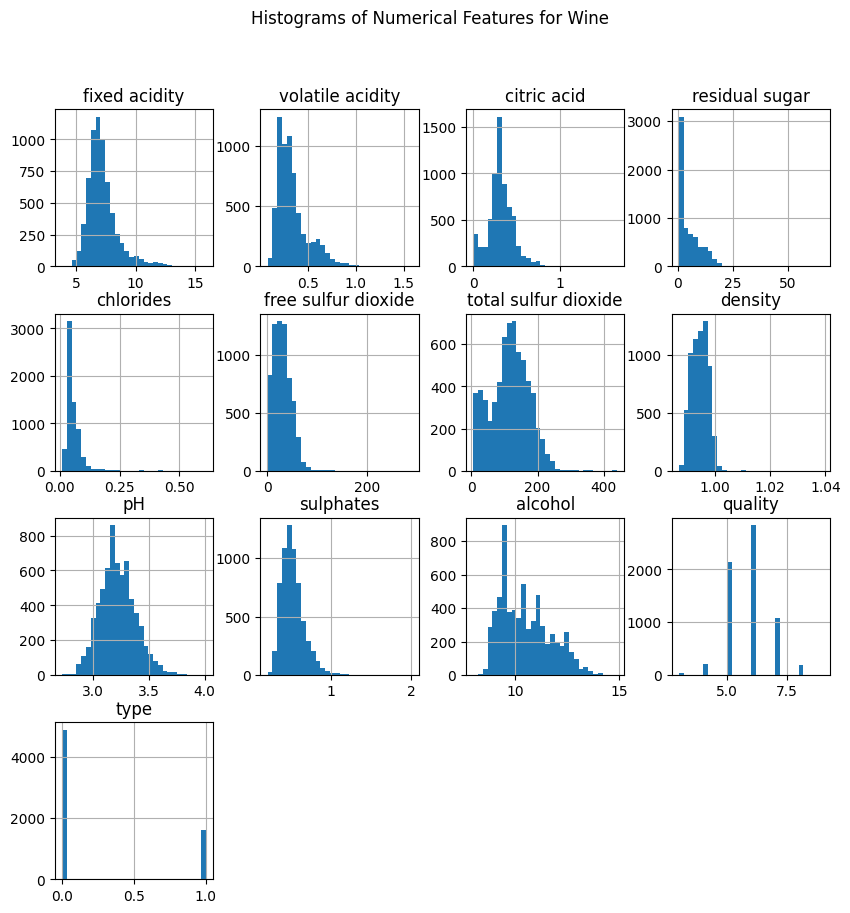

In [ ]:
# code for 1.2
data.hist(bins=30, figsize=(10, 10))
plt.suptitle("Histograms of Numerical Features for Wine")
plt.show()

Based on our observations of the wine dataset contains a few distributed categories like pH, fixed acidity, and total sulfur dioxide and some skewed categories like alcohol, residual sugar, sulphates. To manage these skewed features we can preform data tranformations that normalizes the variance of the feature and convert it to a gaussian distribution. Some examples are Box-Cox tranformations or simpler methods like the squre root tranformation.

### Question 1.3
Construct and inspect the box plot of categorical features vs target variable. What
do you find?

### Answer 1.3

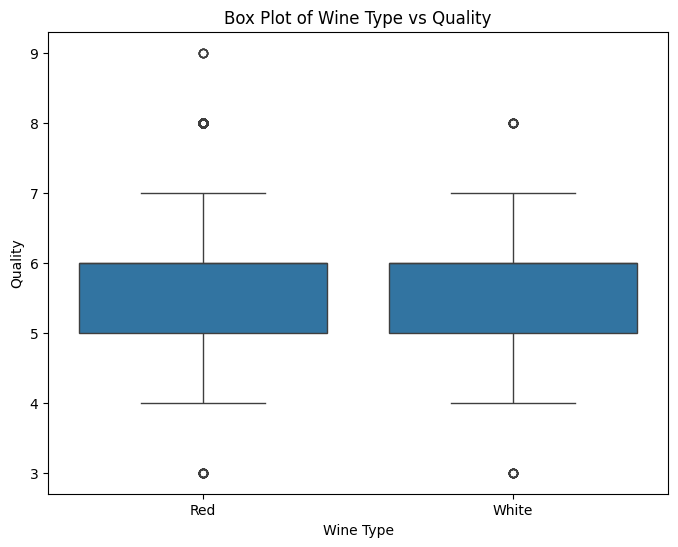

In [ ]:
# Code for 1.3
plt.figure(figsize=(8, 6))

sns.boxplot(x='type', y='quality', data=data)
plt.xticks([0, 1], ['Red', 'White'])
plt.title("Box Plot of Wine Type vs Quality")
plt.xlabel("Wine Type")
plt.ylabel("Quality")

plt.show()

Based on our categories of red and white, there appears to be no significant difference in wine quality, suggesting that they are enjoyed equally by consumers. This is further reinforced by white wine data retaining a similar distributions to red wine inspite of its scarcity in comparison to red wine data.

# Code for 1.4

### Answer 1.4

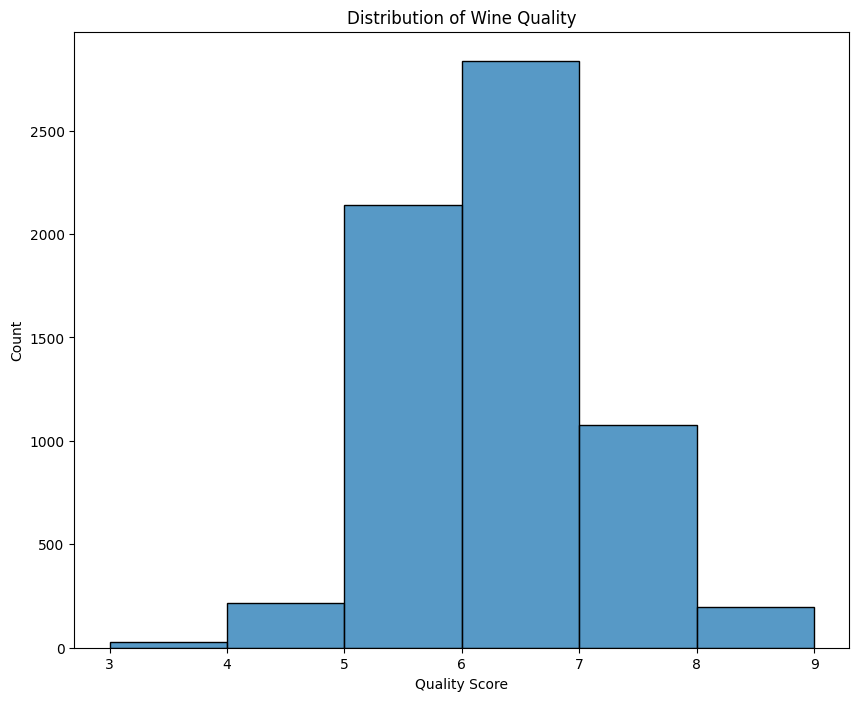

In [ ]:
# code for 1.4
plt.figure(figsize=(10,8))
sns.histplot(data['quality'], bins=6)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

### 3.1.3 Standardization
Standardization of datasets is a common requirement for many machine learning esti-
mators; they might behave badly if the individual features do not more-or-less look like
standard normally distributed data: Gaussian with zero mean and unit variance. If a
feature has a variance that is orders of magnitude larger than others, it might dominate
the objective function and make the estimator unable to learn from other features cor-
rectly as expected.

### Question 2.1
Standardize feature columns and prepare them for training.

### Answer 2.1

In [ ]:
# Code for 2.1
scaler = StandardScaler()

features = data.loc[:, data.columns != "quality"]

quality = data.quality

features_scaled = scaler.fit_transform(features)

features_scaled_df = pd.DataFrame(features_scaled, columns = features.columns)

print(features_scaled_df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.142473          2.188833    -2.192833       -0.744778   0.569958   
1       0.451036          3.282235    -2.192833       -0.597640   1.197975   
2       0.451036          2.553300    -1.917553       -0.660699   1.026697   
3       3.073817         -0.362438     1.661085       -0.744778   0.541412   
4       0.142473          2.188833    -2.192833       -0.744778   0.569958   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -1.100140             -1.446359  1.034993  1.813090   0.193097   
1            -0.311320             -0.862469  0.701486 -0.115073   0.999579   
2            -0.874763             -1.092486  0.768188  0.258120   0.797958   
3            -0.762074             -0.986324  1.101694 -0.363868   0.327510   
4            -1.100140             -1.446359  1.034993  1.813090   0.193097   

    alcohol     type  
0 -0.915464  1.75019  
1 -0.58006

### 3.1.4 Feature Selection
- sklearn.feature selection.mutual info regression function returns estimated
mutual information between each feature and the label. Mutual information (MI)
between two random variables is a non-negative value which measures the depen-
dency between the variables. It is equal to zero if and only if two random variables
are independent, and higher values mean higher dependency.
- sklearn.feature selection.f regression function provides F scores, which is a
way of comparing the significance of the improvement of a model, with respect to
the addition of new variables.

### Question 2.2
You **may** use these functions to select features that yield better regression results (especially in the classical models). Describe how this step qualitatively affects the performance of your models in terms of test RMSE. Is it true for all model types? Also list two features for either dataset that has the lowest MI w.r.t to the target.

### Answer 2.2

In [ ]:
# Code for 2.2
mi_scores = mutual_info_regression(features_scaled_df, quality)

f_scores, p_values = f_regression(features_scaled_df, quality)

mi_scores_df = pd.DataFrame({'Feature': features.columns, 'MI Score': mi_scores})

f_scores_df = pd.DataFrame({'Feature': features.columns, 'F Score': f_scores, 'p-value': p_values})


print("Mutual Information Scores:")
print(mi_scores_df.sort_values(by='MI Score', ascending=False))

print("F-Scores:")
print(f_scores_df.sort_values(by='F Score', ascending=False))

Mutual Information Scores:
                 Feature  MI Score
10               alcohol  0.157496
7                density  0.148336
3         residual sugar  0.065821
6   total sulfur dioxide  0.064483
4              chlorides  0.058112
1       volatile acidity  0.052279
2            citric acid  0.045371
0          fixed acidity  0.044335
5    free sulfur dioxide  0.036587
9              sulphates  0.023447
8                     pH  0.013899
11                  type  0.013760
F-Scores:
                 Feature      F Score        p-value
10               alcohol  1597.640584  1.497544e-312
7                density   670.307800  9.662665e-141
1       volatile acidity   493.351120  2.061959e-105
4              chlorides   272.504696   5.316452e-60
11                  type    93.811807   4.888069e-22
2            citric acid    47.865475   5.001764e-12
0          fixed acidity    38.479055   5.874849e-10
5    free sulfur dioxide    20.041250   7.708445e-06
6   total sulfur dioxide    11.

In [ ]:
# code 2.2 continued

# Selected based on the MI and F1 scores produced in the code block above
selected_features = ['alcohol', 'density', 'volatile acidity', 'chlorides', 'residual sugar']
# selected_features = ['alcohol', 'density', 'total sulfur dioxide', 'chlorides', 'residual sugar']

features_final = features_scaled_df[selected_features]

xr_train, xr_test, yr_train, yr_test = train_test_split(features_final, quality, test_size=0.3, random_state=42)

By first scaling our data and then using the recommended sklearn functions to identify the features that achieve the highest MI and F1 score while minimizing the p-value. These changes influenced the features retained for each type of wine, however, both feature set still have several overlapping categories, signifying that wine quality is consistant acrross the types of wine. By removing features with low correlation we'd expect an improved RMSE value that will make models more effienct especially when using linear models. However, this performance gain may not be observed by all models, particularly like random forest which are robostly designed to ignore irrelevent features.

*From this point on, you are free to use any combination of features, as long as the performance on the regression model is on par (or slightly worse) than the Neural Network
model.*

### 3.2 Training
Once the data is prepared, we would like to train multiple algorithms and compare their
performance using average RMSE from 10-fold cross-validation (please refer to part 3.3).

### 3.3 Evaluation
Perform 10-fold cross-validation and measure average RMSE errors for training and validation sets. For random forest model, measure “Out-of-Bag Error” (OOB) as well.

### 3.3.1 Linear Regression
What is the objective function? Train three models: (a) ordinary least squares (linear
regression without regularization), (b) Lasso and (c) Ridge regression, and answer the
following questions.

### Question 4.1
Explain how each regularization scheme affects the learned parameter set.

In [ ]:
# Function to compute training and validation RMSE using 10-CV
def compute_cv_rmse(model, X, y):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    train_rmse_list = []
    val_rmse_list = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        # Training RMSE
        y_train_pred = model.predict(X_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        train_rmse_list.append(train_rmse)

        # Validation RMSE
        y_val_pred = model.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_rmse_list.append(val_rmse)

    return np.mean(train_rmse_list), np.mean(val_rmse_list)

# Linear Regression
LR_model = LinearRegression()
LR_train_rmse, LR_val_rmse = compute_cv_rmse(LR_model, xr_train, yr_train)
print(f"Linear Regression - Train RMSE: {LR_train_rmse:.9f}, Validation RMSE: {LR_val_rmse:.9f}")

# Lasso Regression
LAS_model = Lasso(alpha=0.1)
LAS_train_rmse, LAS_val_rmse = compute_cv_rmse(LAS_model, xr_train, yr_train)
print(f"Lasso Regression - Train RMSE: {LAS_train_rmse:.9f}, Validation RMSE: {LAS_val_rmse:.9f}")

# Ridge Regression
RID_model = Ridge(alpha=1.0)
RID_train_rmse, RID_val_rmse = compute_cv_rmse(RID_model, xr_train, yr_train)
print(f"Ridge Regression - Train RMSE: {RID_train_rmse:.9f}, Validation RMSE: {RID_val_rmse:.9f}")

# Random Forest with 10-fold Cross-Validation
RF_model = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)

RF_train_rmse, RF_val_rmse = compute_cv_rmse(RF_model, xr_train, yr_train)
print(f"Random Forest - Train RMSE: {RF_train_rmse:.9f}, Validation RMSE: {RF_val_rmse:.9f}")

# Train Random Forest on the full training set and compute Out-of-Bag (OOB) RMSE
RF_model.fit(xr_train, yr_train)
oob_rmse = np.sqrt(mean_squared_error(yr_train, RF_model.oob_prediction_))
print(f"Random Forest - OOB RMSE: {oob_rmse:.4f}")


Linear Regression - Train RMSE: 0.751047319, Validation RMSE: 0.751497153
Lasso Regression - Train RMSE: 0.769914788, Validation RMSE: 0.769514494
Ridge Regression - Train RMSE: 0.751047350, Validation RMSE: 0.751496263
Random Forest - Train RMSE: 0.251912908, Validation RMSE: 0.673838074
Random Forest - OOB RMSE: 0.6713


### Answer 4.1
The main goal of regularization is to prevent overfitting by adding a penalty term to the loss function which influences the learned params. in different ways. The equation for **ordinary least squares** is shown below:

$$J(\theta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In this scheme, there is no regularization because there is no penalty term applied.In this case, the model fits the training set as closely as possible and can frequently lead to overfitting. In the intital results above, the RMSE for ridge and OLS are nearly identical, this shows that the regularization has little effect so that dataset may already be well confditioned or there may be not too many strongly correlated features.

The next regularization is Lasso regularization (L1 regularization). The equation is as follows:

$$J(\theta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\theta_j|$$

This scheme enourages weight sparsity, pushing many weights to absolutely zero and favoring more highly correlated weights. This effectively performs feature selection and can potentially lead to underfitting. In this case, based on the tests performed above, lasso performed the worst (by a small margin). This could be attributed to the fact that we already performed feature selection so the features left are the most highly correlated and we do not need to further force weights to 0.

The next case is ridge regression (L2 regularization). The equation is as follows:

$$J(\theta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \theta_j^2$$

Ridge adds an L2 penalty. The L2 penalty enforces weight decay. It shrinks coefficients but does not force them to zero. In the case here, it seems that OLS and risge are highly correlated in their performance so it seems that the ridge regression does not have much of an affect i.e. regularization does not effect muc. This shows that the data is well-conditioned and doesn't have extreme multicollinearity. Also means that potentially features don't have strong correlations.

### Question 4.2
Report your choice of the best regularization scheme along with the optimal penalty
parameter and explain how you computed it.

Lasso Alpha: 0.0001 - Train RMSE: 0.751047, Validation RMSE: 0.751496
Lasso Alpha: 0.0001 - Train RMSE: 0.751047, Validation RMSE: 0.751496
Lasso Alpha: 0.0001 - Train RMSE: 0.751047, Validation RMSE: 0.751496
Lasso Alpha: 0.0001 - Train RMSE: 0.751047, Validation RMSE: 0.751496
Lasso Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751496
Lasso Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751496
Lasso Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751496
Lasso Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751495
Lasso Alpha: 0.0003 - Train RMSE: 0.751048, Validation RMSE: 0.751495
Lasso Alpha: 0.0003 - Train RMSE: 0.751048, Validation RMSE: 0.751495
Lasso Alpha: 0.0003 - Train RMSE: 0.751048, Validation RMSE: 0.751495
Lasso Alpha: 0.0004 - Train RMSE: 0.751048, Validation RMSE: 0.751495
Lasso Alpha: 0.0004 - Train RMSE: 0.751049, Validation RMSE: 0.751495
Lasso Alpha: 0.0005 - Train RMSE: 0.751049, Validation RMSE: 0.751495
Lasso Alpha: 0.0005 

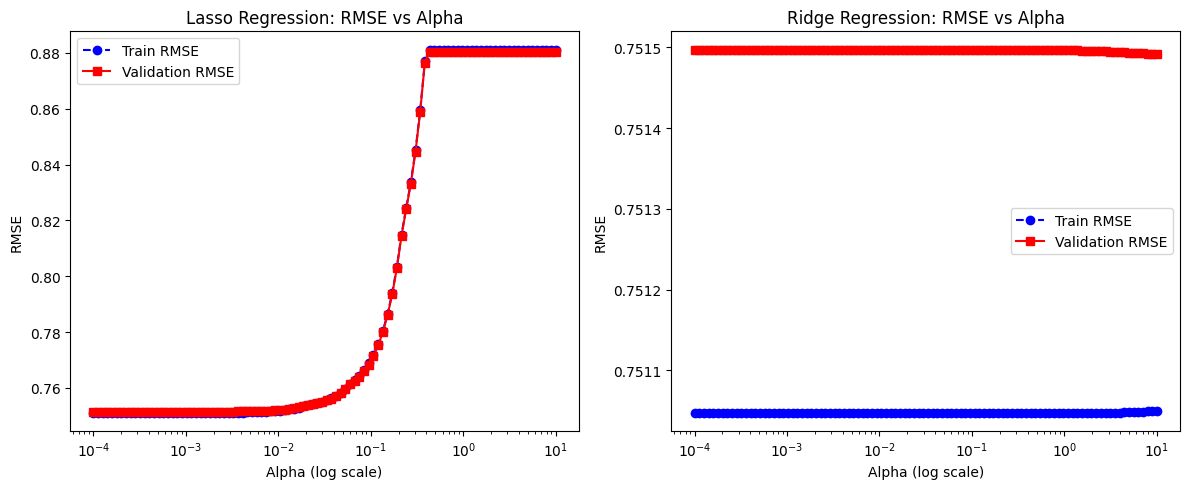

OLS (No Regularization) - Train RMSE: 0.751047319, Validation RMSE: 0.751497153
Best Lasso Regression (alpha=0.0004037017258596554) - Train RMSE: 0.751048619, Validation RMSE: 0.751494616
Best Ridge Regression (alpha=10.0) - Train RMSE: 0.751050325, Validation RMSE: 0.751491069


In [ ]:
# Code for 4.2
# Define alpha values for hyperparameter tuning  (0.0001 to 10)
alpha_values = np.logspace(-4, 1, 100)

# ordinary least squares
LR_model = LinearRegression()
LR_train_rmse, LR_val_rmse = compute_cv_rmse(LR_model, xr_train, yr_train)

# Store RMSE values for plotting
lasso_train_rmse_list = []
lasso_val_rmse_list = []
ridge_train_rmse_list = []
ridge_val_rmse_list = []

# Lasso Regression
for alpha in alpha_values:
    model = Lasso(alpha=alpha, max_iter=10000)
    train_rmse, val_rmse = compute_cv_rmse(model, xr_train, yr_train)

    lasso_train_rmse_list.append(train_rmse)
    lasso_val_rmse_list.append(val_rmse)

    print(f"Lasso Alpha: {alpha:.4f} - Train RMSE: {train_rmse:.6f}, Validation RMSE: {val_rmse:.6f}")

# Lasso Regression with hyperparameter tuning
LAS_model = Lasso()
LAS_grid = GridSearchCV(LAS_model, {'alpha': alpha_values}, scoring='neg_root_mean_squared_error', cv=10)
LAS_grid.fit(xr_train, yr_train)
LAS_best_alpha = LAS_grid.best_params_['alpha']

# Train with the best alpha
LAS_model_best_alpha = Lasso(alpha=LAS_best_alpha)
LAS_model_best_alpha_train_rmse, LAS_model_best_alpha_val_rmse = compute_cv_rmse(LAS_model_best_alpha, xr_train, yr_train)

# Ridge Regression
for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    train_rmse, val_rmse = compute_cv_rmse(model, xr_train, yr_train)

    ridge_train_rmse_list.append(train_rmse)
    ridge_val_rmse_list.append(val_rmse)

    print(f"Ridge Alpha: {alpha:.4f} - Train RMSE: {train_rmse:.6f}, Validation RMSE: {val_rmse:.6f}")

# Ridge Regression with hyperparameter tuning
RID_model = Ridge()
RID_grid = GridSearchCV(RID_model, {'alpha': alpha_values}, scoring='neg_root_mean_squared_error', cv=10)
RID_grid.fit(xr_train, yr_train)
RID_best_alpha = RID_grid.best_params_['alpha']

# Train with best alpha
RID_model_best_alpha = Ridge(alpha=RID_best_alpha)
RID_model_best_alpha_train_rmse, RID_model_best_alpha_val_rmse = compute_cv_rmse(RID_model_best_alpha, xr_train, yr_train)

# Plot RMSE vs Alpha
plt.figure(figsize=(12, 5))

# Lasso RMSE Plot
plt.subplot(1, 2, 1)
plt.plot(alpha_values, lasso_train_rmse_list, label='Train RMSE', linestyle='--', marker='o', color='blue')
plt.plot(alpha_values, lasso_val_rmse_list, label='Validation RMSE', linestyle='-', marker='s', color='red')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Lasso Regression: RMSE vs Alpha')
plt.legend()

# Ridge RMSE Plot
plt.subplot(1, 2, 2)
plt.plot(alpha_values, ridge_train_rmse_list, label='Train RMSE', linestyle='--', marker='o', color='blue')
plt.plot(alpha_values, ridge_val_rmse_list, label='Validation RMSE', linestyle='-', marker='s', color='red')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge Regression: RMSE vs Alpha')
plt.legend()

plt.tight_layout()
plt.show()

# Results
print(f"OLS (No Regularization) - Train RMSE: {LR_train_rmse:.9f}, Validation RMSE: {LR_val_rmse:.9f}")
print(f"Best Lasso Regression (alpha={LAS_best_alpha}) - Train RMSE: {LAS_model_best_alpha_train_rmse:.9f}, Validation RMSE: {LAS_model_best_alpha_val_rmse:.9f}")
print(f"Best Ridge Regression (alpha={RID_best_alpha}) - Train RMSE: {RID_model_best_alpha_train_rmse:.9f}, Validation RMSE: {RID_model_best_alpha_val_rmse:.9f}")

### Answer 4.2
I swept over an alpha range (0.0001 to 10) (alpha_values = np.logspace(-4, 1, 100)). for lassos and ridge regression. The optimal choice is shown above (Best Ridge Regression (alpha=10.0) - Train RMSE: 0.751050325, Validation RMSE: 0.751491069)

### Question 4.3
Does feature standardization play a role in improving the model performance (in
the cases with ridge regularization)? Justify your answer.

In [ ]:
# Code for 4.3

# Retrieve unscaled data
features_final_unscaled = features[selected_features]

# Split unscaled data
xr_train_unscaled, xr_test_unscaled, yr_train_unscaled, yr_test_unscaled = train_test_split(
    features_final_unscaled, quality, test_size=0.3, random_state=42
)

# Ridge Regression
for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    train_rmse, val_rmse = compute_cv_rmse(model, xr_train_unscaled, yr_train_unscaled)

    print(f"Ridge Alpha: {alpha:.4f} - Train RMSE: {train_rmse:.6f}, Validation RMSE: {val_rmse:.6f}")

# Ridge Regression on Unscaled Data
RID_model_unscaled = Ridge()
RID_grid_unscaled = GridSearchCV(RID_model_unscaled, {'alpha': alpha_values}, scoring='neg_root_mean_squared_error', cv=10)
RID_grid_unscaled.fit(xr_train_unscaled, yr_train_unscaled)
RID_best_alpha_unscaled = RID_grid_unscaled.best_params_['alpha']

# Train Ridge with best alpha (Unscaled Data)
RID_model_best_alpha_unscaled = Ridge(alpha=RID_best_alpha_unscaled)
RID_model_best_alpha_unscaled_train_rmse, RID_model_best_alpha_unscaled_val_rmse = compute_cv_rmse(RID_model_best_alpha_unscaled, xr_train_unscaled, yr_train_unscaled)

print(f"Ridge Regression (Unscaled, alpha={RID_best_alpha_unscaled}) - Train RMSE: {RID_model_best_alpha_unscaled_train_rmse:.9f}, Validation RMSE: {RID_model_best_alpha_unscaled_val_rmse:.9f}")


Ridge Alpha: 0.0001 - Train RMSE: 0.751047, Validation RMSE: 0.751495
Ridge Alpha: 0.0001 - Train RMSE: 0.751047, Validation RMSE: 0.751494
Ridge Alpha: 0.0001 - Train RMSE: 0.751048, Validation RMSE: 0.751494
Ridge Alpha: 0.0001 - Train RMSE: 0.751048, Validation RMSE: 0.751494
Ridge Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751493
Ridge Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751493
Ridge Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751493
Ridge Alpha: 0.0002 - Train RMSE: 0.751048, Validation RMSE: 0.751492
Ridge Alpha: 0.0003 - Train RMSE: 0.751048, Validation RMSE: 0.751492
Ridge Alpha: 0.0003 - Train RMSE: 0.751048, Validation RMSE: 0.751491
Ridge Alpha: 0.0003 - Train RMSE: 0.751049, Validation RMSE: 0.751490
Ridge Alpha: 0.0004 - Train RMSE: 0.751049, Validation RMSE: 0.751490
Ridge Alpha: 0.0004 - Train RMSE: 0.751049, Validation RMSE: 0.751489
Ridge Alpha: 0.0005 - Train RMSE: 0.751050, Validation RMSE: 0.751488
Ridge Alpha: 0.0005 

### Answer 4.3
Shown in the code snippet above and the results, I unscaled the features and then re-ran the training and validation on set. The best alpha on the set was Ridge Regression (Unscaled, alpha=0.001291549665014884) - Train RMSE: 0.751064111, Validation RMSE: 0.751485131. This is compared to above for scaled features: (Best Ridge Regression (alpha=10.0) - Train RMSE: 0.751050325, Validation RMSE: 0.751491069). Given these results, scaling is not playing a major role with this data set and feature selection. Typically scaling is nesecarry for ridge regression. It improves ridge regression by ensuring all fratures contribute equally to the L2 penalty which prevents coefficient shrinkage and bis. In this case, the datasets features could already have similar ranges so standardization doesnt have a very meaningful impact.

### Question 4.4
Some linear regression packages return p-values for different features$^{2}$. What is the
meaning of these p-values and how can you infer the most significant features? A
qualitative reasoning is sufficient.

### Answer 4.4
In question 2.2. we showed an analysis of p-values returned. P values indicate the statistic significance of each feature in predicting the target variable. Low p-value -> feature is very signifacnt. High p-value -> feature is quite insignificant. To infer the most significat features you can create a ranking of p-values (as shown in 2.2) the ones with the lowest p-value are very significant.

### 3.3.2 Polynomial Regression
Perform polynomial regression by crafting products of features you selected in part 3.1.4
up to a certain degree (max degree 6) and applying ridge regression on the compound
features. You can use scikit-learn library to build such features. Avoid overfitting by
proper regularization. Answer the following:

In [ ]:
# Code for 3.3.2

# Perform polynoial regression
degrees = [1, 2, 3, 4, 5, 6]

results = []

# Lopp through each degree
for degree in degrees:
    ridge_pipeline = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), Ridge())

    # Define parameter grid
    param_grid = {'ridge__alpha': alpha_values}

    # GridSearchCV for best alpha at this degree
    ridge_grid = GridSearchCV(ridge_pipeline, param_grid, scoring='neg_root_mean_squared_error', cv=10)
    ridge_grid.fit(xr_train, yr_train)

    # Get best parameters & model
    best_alpha = ridge_grid.best_params_['ridge__alpha']
    best_rmse_val = -ridge_grid.best_score_
    best_model = ridge_grid.best_estimator_

    # Evaluate on test set
    yr_pred = best_model.predict(xr_test)
    rmse_test = np.sqrt(mean_squared_error(yr_test, yr_pred))

    # Store results
    results.append({'Degree': degree, 'Best Alpha': best_alpha, 'Validation RMSE': best_rmse_val, 'Test RMSE': rmse_test})

# Convert for comparison
results_df = pd.DataFrame(results)

# Get best performing model
best_row = results_df.loc[results_df['Test RMSE'].idxmin()]
best_degree = best_row['Degree']
best_alpha = best_row['Best Alpha']
best_rmse_test = best_row['Test RMSE']

print(results_df)

# Print best performing model
print(f"\nBest Polynomial Degree: {best_degree}")
print(f"Best Ridge Alpha: {best_alpha}")
print(f"Best Test RMSE: {best_rmse_test:.9f}")


   Degree  Best Alpha  Validation RMSE  Test RMSE
0       1   10.000000         0.750891   0.737461
1       2   10.000000         0.760180   0.730690
2       3    3.511192         0.735278   0.724796
3       4   10.000000         8.732566   0.738289
4       5    1.384886         1.148785   0.789161
5       6    0.075646        13.454368   2.064454

Best Polynomial Degree: 3.0
Best Ridge Alpha: 3.5111917342151275
Best Test RMSE: 0.724796024


### Question 5.1
What are the most salient features? Why?

In [ ]:
# Train the best polynomial Ridge model
best_pipeline = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), StandardScaler(), Ridge(alpha=best_alpha))
best_pipeline.fit(xr_train, yr_train)

# Extract feature names
poly_features = best_pipeline.named_steps['polynomialfeatures'].get_feature_names_out(input_features=xr_train.columns)

# Extract Ridge regression coefficients
ridge_coefficients = best_pipeline.named_steps['ridge'].coef_

# Create DataFrame to rank feature importance
coeff_df = pd.DataFrame({'Feature': poly_features, 'Coefficient': ridge_coefficients})
coeff_df['Abs Coefficient'] = coeff_df['Coefficient'].abs()

# Sort by absolute coefficient magnitude (strongest predictors)
coeff_df_sorted = coeff_df.sort_values(by='Abs Coefficient', ascending=False)

# Print top 10 most important features
print("\nTop 10 Most Important Features:")
print(coeff_df_sorted.head(10))


Top 10 Most Important Features:
                                    Feature  Coefficient  Abs Coefficient
36               density^2 volatile acidity    -0.567602         0.567602
0                                   alcohol     0.530742         0.530742
13                   density residual sugar    -0.434990         0.434990
2                          volatile acidity    -0.315704         0.315704
37                      density^2 chlorides    -0.308375         0.308375
43         density chlorides residual sugar     0.302595         0.302595
41  density volatile acidity residual sugar     0.284521         0.284521
10                                density^2     0.282696         0.282696
50        volatile acidity residual sugar^2     0.258230         0.258230
54                         residual sugar^3    -0.239804         0.239804


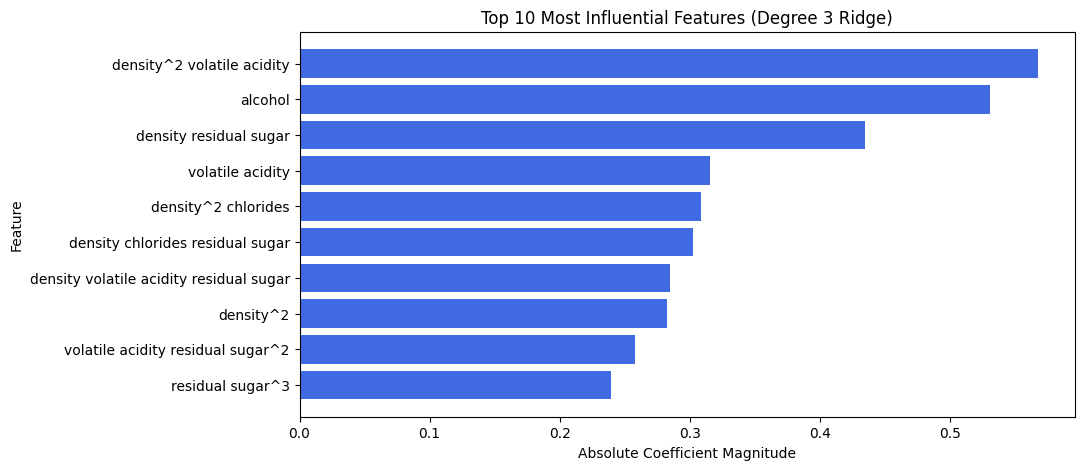

In [ ]:
# Plot top 10 features
plt.figure(figsize=(10, 5))
top_features = coeff_df_sorted.head(10)
plt.barh(top_features['Feature'], top_features['Abs Coefficient'], color='royalblue')
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features (Degree 3 Ridge)")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


### Answer 5.1
The most salient features are determined by their absolute coefficient magnitude in Ridge Regression. The higher the absolute coefficient, the stronger the feature's impact on the target variable. These features are shown in the table. Above I trained a grid of alpha parameters for each polynomial and then translated the feature names and have listed above.

### Question 5.2
What degree of polynomial is best? How did you find the optimal degree? What
does a very high-order polynomial imply about the fit on the training data? What
about its performance on testing data?

### Answer 5.2
The best polynomial degree is 3, as it achieves the lowest test RMSE (0.7248) with Ridge regularization (α=3.52). I found this through doing a sweep of alpha values alpha_values = np.logspace(-4, 1, 100) and polynomial degrees [1, 2, 3, 4, 5, 6]. Very high order polynomials tend to overfit the data as they match complexity. This implies that the training RMSE will be low and validation will be high (as seen). The higher order the polynomial the more complexity can be captured but this comes with a risk (as seen in the testing data).

### 3.3.3 Neural Network
You will train a multi-layer perceptron (fully connected neural network). You can simply use the sklearn implementation:

### Question 6.1
Adjust your network size (number of hidden neurons and depth), and weight decay
as regularization. Find a good hyper-parameter set systematically (no more than
20 experiments in total).

In [ ]:
# Code for 3.3.3 (if necessary)

# train a multi-layer perceptron

# make sure inputs are scaled
scaler = StandardScaler()
xr_train_scaled = scaler.fit_transform(xr_train)
xr_test_scaled = scaler.transform(xr_test)

# parameter grid for hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (50, 50, 50)],
    'alpha': np.logspace(-4, -1, 4),
    'learning_rate_init': [0.001, 0.01]
}

# create a multi-layer perceptron regressor
mlp = MLPRegressor(activation='relu', solver='adam', max_iter=1000, random_state=42)

# grid search for hyperparameter tuning
mlp_grid = GridSearchCV(mlp, param_grid, scoring='neg_root_mean_squared_error', cv=10)
mlp_grid.fit(xr_train_scaled, yr_train)

# get best parameters
best_params = mlp_grid.best_params_
best_mlp = mlp_grid.best_estimator_
best_rmse_val = -mlp_grid.best_score_

# evaluate on test set
yr_pred = best_mlp.predict(xr_test_scaled)
rmse_test = np.sqrt(mean_squared_error(yr_test, yr_pred))

# print results
print(f"Best Parameters: {best_params}")
print(f"Validation RMSE: {best_rmse_val:.9f}")
print(f"Test RMSE: {rmse_test:.9f}")


Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.001}
Validation RMSE: 0.725234862
Test RMSE: 0.718555131


### Answer 6.1
Above, I swept a grid of parameters: 'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (50, 50, 50)], 'alpha': np.logspace(-4, -1, 4), 'learning_rate_init': [0.001, 0.01]. The best option is shown above as a result:

Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.001}
Validation RMSE: 0.725234862
Test RMSE: 0.718555131

### Question 6.2
How does the performance generally compare with linear regression? Why?

### Answer 6.2
Linear regression best result: (Best Ridge Regression (alpha=10.0) - Train RMSE: 0.751050325, Validation RMSE: 0.751491069)

NN Best result: Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.001}
Validation RMSE: 0.725234862
Test RMSE: 0.718555131

The results are quite comparable. the linear regression validation RMSE is higher by ~0.05 which is understandable. I did not test on all possible alpha values and this is a basic technique to calulate the gradient and most of the time the data contains a non-linear relationship (which the linear model doesn't capture but NN's do very well).

Although it is worth questioning if the added complexity is worth the time for the 0.05 performance increase.

### Question 6.3
What activation function did you use for the output and why? You may use none.

### Answer 6.3
We used the default linear (identity) activation for the output layer, which is ideal for regression since it allows unrestricted real-valued predictions. Other activations (ReLU, sigmoid, softmax) would limit output range, making them unsuitable.

### Question 6.4
What is the risk of increasing the depth of the network too far?

### Answer 6.4
There are several risks of increasing the depth of the network too far including preventing vanishing gradients and overfitting. Increasing the depth of a NN increses complexity (much like higher order degree polynomial regressions). This can have many benefits but also leads to some serious potential issues:

- Overfitting – Memorizes training data, reducing generalization.
- Vanishing/Exploding Gradients – Slows or destabilizes training.
- Longer Training Time – Increases computational cost.
- Diminishing Returns – Extra layers may not improve performance

### 3.3.4 Random Forest
We will train a random forest regression model on datasets, and answer the following:

### Question 7.1
Random forests have the following hyper-parameters:
- Maximum number of features;
- Number of trees;
- Depth of each tree;

Explain how these hyper-parameters affect the overall performance. Describe if
and how each hyper-parameter results in a regularization effect during training.

In [ ]:
# Code for 7.1 (if necessary)
max_feature = [1, 2, 3]
num_tree = [30, 50, 100]
depth = [2, 3, 4]

X_train, X_test, y_train, y_test = xr_train, xr_test, yr_train, yr_test

rmse_rf = []
oob = []
test_rmse = []

best_rmse = float('inf')
best_oob = float('inf')
best_test_rmse = float('inf')

for f in max_feature:
    for t in num_tree:
        for d in depth:
            model = RandomForestRegressor(
                n_estimators=t,
                max_depth=d,
                max_features=f,
                oob_score=True,
                random_state=42
            )
            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            local_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
            rmse_rf.append(local_rmse)

            if hasattr(model, 'oob_prediction_'):
                local_oob = np.sqrt(mean_squared_error(y_train, model.oob_prediction_))
            else:
                local_oob = float('inf')
            oob.append(local_oob)

            y_test_pred = model.predict(X_test)
            local_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            test_rmse.append(local_test_rmse)

            print(f"Config: Max Features = {f}, Num Trees = {t}, Max Depth = {d} | RMSE = {local_rmse:.4f}, OOB = {local_oob:.4f}, Test RMSE = {local_test_rmse:.4f}")

            if local_rmse < best_rmse:
                best_rmse = local_rmse
                best_feature = f
                best_num_tree = t
                best_depth = d

            if local_oob < best_oob:
                best_oob = local_oob
                best_oob_feature = f
                best_oob_num_tree = t
                best_oob_depth = d

            if local_test_rmse < best_test_rmse:
                best_test_rmse = local_test_rmse
                best_test_feature = f
                best_test_num_tree = t
                best_test_depth = d

print(f"\nBest OOB RMSE: {best_oob:.4f} with params {{'Max Features': {best_oob_feature}, 'Num Trees': {best_oob_num_tree}, 'Max Depth': {best_oob_depth}}}")
print(f"Best Test RMSE: {best_test_rmse:.4f} with params {{'Max Features': {best_test_feature}, 'Num Trees': {best_test_num_tree}, 'Max Depth': {best_test_depth}}}")


Config: Max Features = 1, Num Trees = 30, Max Depth = 2 | RMSE = 0.7919, OOB = 0.7970, Test RMSE = 0.7668
Config: Max Features = 1, Num Trees = 30, Max Depth = 3 | RMSE = 0.7726, OOB = 0.7829, Test RMSE = 0.7519
Config: Max Features = 1, Num Trees = 30, Max Depth = 4 | RMSE = 0.7526, OOB = 0.7662, Test RMSE = 0.7414
Config: Max Features = 1, Num Trees = 50, Max Depth = 2 | RMSE = 0.7965, OOB = 0.8010, Test RMSE = 0.7713
Config: Max Features = 1, Num Trees = 50, Max Depth = 3 | RMSE = 0.7764, OOB = 0.7856, Test RMSE = 0.7557
Config: Max Features = 1, Num Trees = 50, Max Depth = 4 | RMSE = 0.7552, OOB = 0.7675, Test RMSE = 0.7435
Config: Max Features = 1, Num Trees = 100, Max Depth = 2 | RMSE = 0.7909, OOB = 0.7956, Test RMSE = 0.7673
Config: Max Features = 1, Num Trees = 100, Max Depth = 3 | RMSE = 0.7692, OOB = 0.7777, Test RMSE = 0.7508
Config: Max Features = 1, Num Trees = 100, Max Depth = 4 | RMSE = 0.7491, OOB = 0.7621, Test RMSE = 0.7386
Config: Max Features = 2, Num Trees = 30, M

### Answer 7.1
1. Maximum number of features:
   This parameter limits how many features can be considered at each split. Lower values can increase regularization by reducing variance among the individual trees and limiting their reliance on the same dominant features, which promotes greater diversity within the forest.

2. Number of trees:
   This parameter sets how many decision trees are in the ensemble. More trees usually reduce overfitting by averaging predictions across a larger set of models. However, an excessive number of trees may introduce additional computational cost and does not always improve performance.

3. Depth of each tree:
   This parameter restricts how deep each decision tree can grow. Higher depth allows more complex decision boundaries but increases the risk of overfitting. Conversely, very shallow trees may underfit. Adjusting tree depth balances the bias–variance trade-off and contributes to the regularization of the ensemble.

Overall, these hyperparameters control model complexity and the balance between bias and variance. By limiting how features or structures are used in each tree, they help regularize the random forest and improve its ability to generalize to new data.

### Question 7.2
How do random forests create a highly non-linear decision boundary despite the fact that all we do at each layer is apply a threshold on a feature?

### Answer 7.2
Random forests create a highly non-linear boundary by combining multiple decision trees. Each tree learns splits based on feature thresholds, but they use different subsets of data (bagging) and different subsets of features, which leads to varied decision boundaries. When the results of these diverse trees are averaged, the ensemble captures a broader range of nonlinearities and interactions than any single tree could achieve, resulting in a more flexible decision boundary.

### Question 7.3
Randomly pick a tree in your random forest model (with maximum depth of 4) and
plot its structure. Which feature is selected for branching at the root node? What can you infer about the importance of this feature as opposed to others? Do the important features correspond to what you got in part 3.3.1?

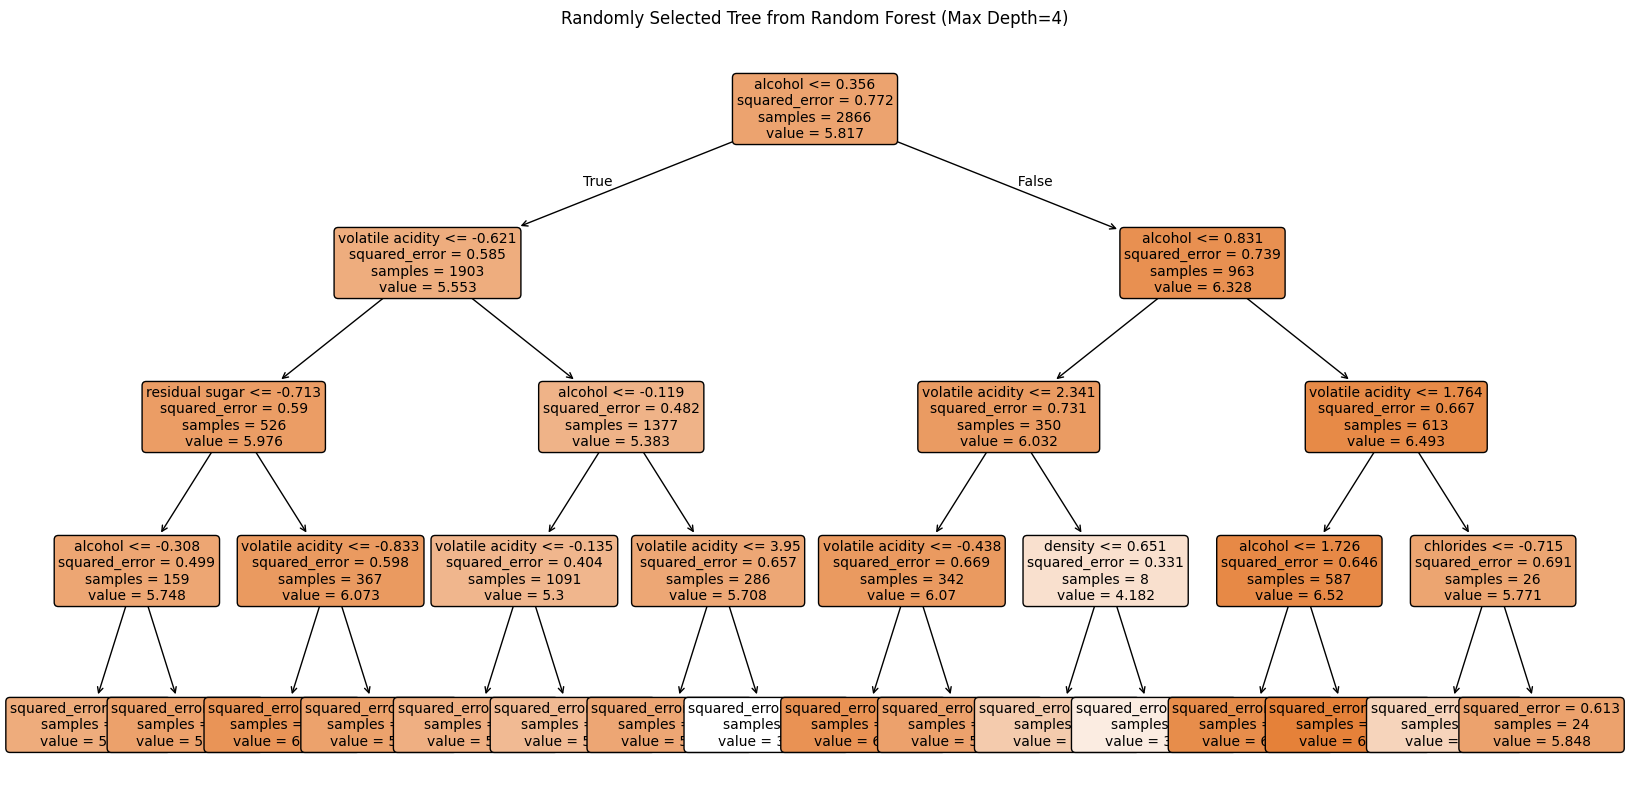

Feature used at root node: alcohol


In [ ]:
# Code for 7.3 (if necessary)
from sklearn.tree import plot_tree
best_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    max_features=3,
    oob_score=True,
    random_state=42
)
best_model.fit(xr_train, yr_train)

random_tree = best_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    random_tree,
    feature_names=xr_train.columns,
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=10
)
plt.title("Randomly Selected Tree from Random Forest (Max Depth=4)")
plt.show()

root_node_feature = random_tree.tree_.feature[0]
print(f"Feature used at root node: {xr_train.columns[root_node_feature]}")


Feature used at root node: alcohol

Alcohol or density is selected for branching at the root node in the trees we examined.

We can infer that whichever feature appears at the root is the most important one in that particular tree.

Yes, both of these features match our findings in part 3.3.1.

### Question 7.4
Measure “Out-of-Bag Error” (OOB). Explain what OOB error and R2 score means.

### Answer 7.4
OOB: 0.74
OOB error is a measure of how well a random forest model predicts data points that were not included in the subset used to train each individual tree. In random forest training, each tree is built on a random sample of the original dataset, and the data points left out of this sample form the out-of-bag set for that tree. By comparing the predicted values on these left-out points to their actual values, the model’s OOB error can be determined. This metric is often used to guide hyperparameter tuning, such as adjusting the number of trees, and to evaluate how well the model may generalize to new data.

R2 score is an indicator of how much of the variation in a target variable is captured by the model’s predictions. Its value ranges from 0 to 1, with 0 meaning the model explains none of the variation and 1 meaning it explains all of it. In regression tasks, the R2 score is a common way to judge how closely the model’s predictions match the real data. A higher R2 score indicates a stronger alignment between predictions and observed values.

### 3.3.5 LightGBM, CatBoost and Bayesian Optimization
Boosted tree methods have shown advantages when dealing with tabular data, and recent
advances make these algorithms scalable to large scale data and enable natural treatment
of (high-cardinality) categorical features. Two of the most successful examples are Light-
GBM and CatBoost.

Both algorithms have many hyperparameters that influence their performance. This
results in large search space of hyperparameters, making the tuning of the hyperparame-
ters hard with naive random search and grid search. Therefore, one may want to utilize
“smarter” hyperparameter search schemes. We specifically explore one of them: Bayesian
optimization.

In this part, pick either one of the datasets and apply LightGBM OR CatBoost. If
you do both, we will only look at the first one.

### Question 8.1
Read the documentation of LightGBM OR CatBoost and determine the important
hyperparameters along with a search space for the tuning of these parameters (keep the search space small).

### Answer 8.1
Based on the CatBoost documentation, four key hyperparameters were identified: “colsample_bylevel” (0.2 to 1), “max_depth” (3 to 10), “num_trees” (100 to 500), and “l2_leaf_reg” (0 to 1). These ranges form a small search space to tune the model while keeping training feasible within typical resource constraints.

### Question 8.2
Apply Bayesian optimization using skopt.BayesSearchCV from scikit-optmize to
find the ideal hyperparameter combination in your search space. Keep your search
space small enough to finish running on a single Google Colab instance within 60
minutes. Report the best hyperparameter set found and the corresponding RMSE.

In [ ]:
# Code for 8.2 (if necessary)
!pip install catboost
!pip install scikit-optimize
from catboost import CatBoostRegressor
from sklearn.tree import export_graphviz
import pydot
from IPython.display import Image
from skopt import BayesSearchCV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.1 MB/s eta 0:00:00


In [ ]:
X_train, X_test, y_train, y_test = xr_train, xr_test, yr_train, yr_test
param_space = {
    'colsample_bylevel': (0.5, 1),
    'max_depth': (3, 10),
    'num_trees': (100, 500),
    'l2_leaf_reg': (0.01, 1)
}
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train columns:", X_train.columns)
print("X_test columns:", X_test.columns)

model = CatBoostRegressor(verbose=0)

opt = BayesSearchCV(
    model,
    param_space,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)

opt.fit(X_train, y_train)

best_params = opt.best_params_
print(f"Best Parameters: {best_params}")

y_pred = opt.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Best RMSE: {rmse:.4f}")


X_train shape: (4547, 5)
X_test shape: (1950, 5)
X_train columns: Index(['alcohol', 'density', 'volatile acidity', 'chlorides',
       'residual sugar'],
      dtype='object')
X_test columns: Index(['alcohol', 'density', 'volatile acidity', 'chlorides',
       'residual sugar'],
      dtype='object')
Best Parameters: OrderedDict([('colsample_bylevel', 0.8125284146910192), ('l2_leaf_reg', 0.01), ('max_depth', 10), ('num_trees', 500)])
Best RMSE: 0.6728


### Answer 8.2
Best Parameters: OrderedDict([('colsample_bylevel', 0.8125284146910192), ('l2_leaf_reg', 0.01), ('max_depth', 10), ('num_trees', 500)])
Best RMSE: 0.6728

### Question 8.3
Qualitatively interpret the effect of the hyperparameters using the Bayesian optimization results: Which of them helps with performance? Which helps with regularization (shrinks the generalization gap)? Which affects the fitting efficiency?

### Answer 8.3
num_trees helps with performance by improving the model's accuracy.

l2_leaf_reg helps with regularization by shrinking the generalization gap.

max_depth affects the fitting efficiency as it controls the maximum depth of each tree; reducing this parameter decreases training time.